###  Import Libraries and Modules


In [3]:
import os
from models.unet import Unet
from models.fpn import FPN
from models.linknet import LinkNet
from models.pspnet import PSPNet
from data.augmentation import Augmentation
from utils.losses import Losses
from utils.metrics import Metrics
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger
from matplotlib import pyplot as plt
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import yaml


2025-04-22 16:54:41.859229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745340882.060543      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745340882.117733      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.14). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### Load Configuration

Load the configuration parameters from a YAML file, which contains various settings such as image size, batch size, paths for training and validation data, learning rate, and other hyperparameters. 


In [4]:
with open("./configs/config.yaml", "r") as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

## Data Preprocessing and Augmentation

Define functions for loading and processing images and masks. The `load_image` function reads an image file, decodes it, resizes it to the specified dimensions, and normalizes the pixel values to a range of [0, 1]. The `load_mask` function does the same for masks, but it reads them as 4-channel PNG images and resizes them to match the image size.

Define a `preprocess` function to apply any preprocessing operations on the images and a separate `augmentation` function to apply data augmentation on both the images and masks.

The `process_path` function is responsible for loading images and masks, and optionally applying augmentation and preprocessing steps. The `load_data` function loads the image and mask file paths, combines them into a dataset, and applies the preprocessing and augmentation functions.

The `prepare_dataset` function prepares the dataset for training by batching, shuffling (for training), and prefetching it for efficiency. The dataset is then split into `train_dataset` and `valid_dataset` for training and validation, respectively.


In [5]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [config['image_size'][0], config['image_size'][1]])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def load_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=4)
    mask = tf.image.resize(mask, [config['image_size'][0], config['image_size'][1]], method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0
    return mask

def preprocess(image, mask, preprocessing_fn):
    image = preprocessing_fn(image)  # Process image as NumPy array
    return image, mask

def augmentation(image, mask, augmentation_fn):

    sample = augmentation_fn(image=image, mask=mask)
    return tf.convert_to_tensor(sample['image']), tf.convert_to_tensor(sample['mask'])

def process_path(image_path, mask_path, augmentation_fn=None, preprocessing_fn=None):
    image = load_image(image_path)
    mask = load_mask(mask_path)
    if augmentation_fn:
        image, mask = tf.numpy_function(lambda img, msk: augmentation(img, msk, augmentation_fn), [image, mask], [tf.float32, tf.float32])
        image.set_shape((config['image_size'][0], config['image_size'][1], 3))
        mask.set_shape((config['image_size'][0], config['image_size'][1], 4))
    
    if preprocessing_fn:
        image, mask = tf.numpy_function(lambda img, msk: preprocess(img, msk, preprocessing_fn), [image, mask], [tf.float32, tf.float32])
    return image, mask

def load_data(images_dir, masks_dir, augmentation=None, preprocessing=None):
    image_paths = tf.data.Dataset.list_files(images_dir + '/*.jpg',shuffle=False)
    mask_paths = tf.data.Dataset.list_files(masks_dir + '/*.png',shuffle=False)

    dataset = tf.data.Dataset.zip((image_paths, mask_paths))

    dataset = dataset.map(lambda img_path, msk_path: process_path(img_path, msk_path, augmentation, preprocessing), num_parallel_calls=tf.data.AUTOTUNE)
    return dataset

train_dataset = load_data(
    images_dir=config['paths']['x_train_dir'], 
    masks_dir=config['paths']['y_train_dir'], 
    augmentation= Augmentation("./configs/augmentation_config.yaml",image_size=(config['image_size'][0], config['image_size'][1],3)).get_training_augmentation(), 
    preprocessing=None
)

valid_dataset = load_data(
    images_dir=config['paths']['x_valid_dir'], 
    masks_dir=config['paths']['y_valid_dir'], 
    augmentation=None,
    preprocessing=None
)

def prepare_dataset(dataset, batch_size, shuffle=False,train=True):
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    if train:
        dataset = dataset.repeat()
    return dataset


train_dataset = prepare_dataset(train_dataset, batch_size=config['BATCH_SIZE'], shuffle=True,train=True)
valid_dataset = prepare_dataset(valid_dataset, batch_size=config['BATCH_SIZE'], shuffle=False,train=False)


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:45: UserWarning: This augmenter is very slow. Try to use ``ElasticTransformation`` instead, which is at least 10x faster.
  original_init(self, **validated_kwargs)
I0000 00:00:1745340895.906847      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
sample = next(iter(train_dataset))
images,masks = sample
image, mask = images[1].numpy(),masks[1].numpy()

### Visualize Sample Data
Display a sample image and its corresponding mask from the training dataset. 


In [7]:
def visualize(images, masks):
    n = len(images)
    plt.figure(figsize=(16, 5 * n))

    for i in range(n):
        plt.subplot(n, 5, 5 * i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i].numpy())
        plt.title("Image")

        for j in range(4):
            plt.subplot(n, 5, 5 * i + 2 + j)
            plt.xticks([])
            plt.yticks([])
            plt.imshow(masks[i][..., j].numpy(), cmap="gray")
            plt.title(f"Mask Channel {j+1}")

    plt.show()


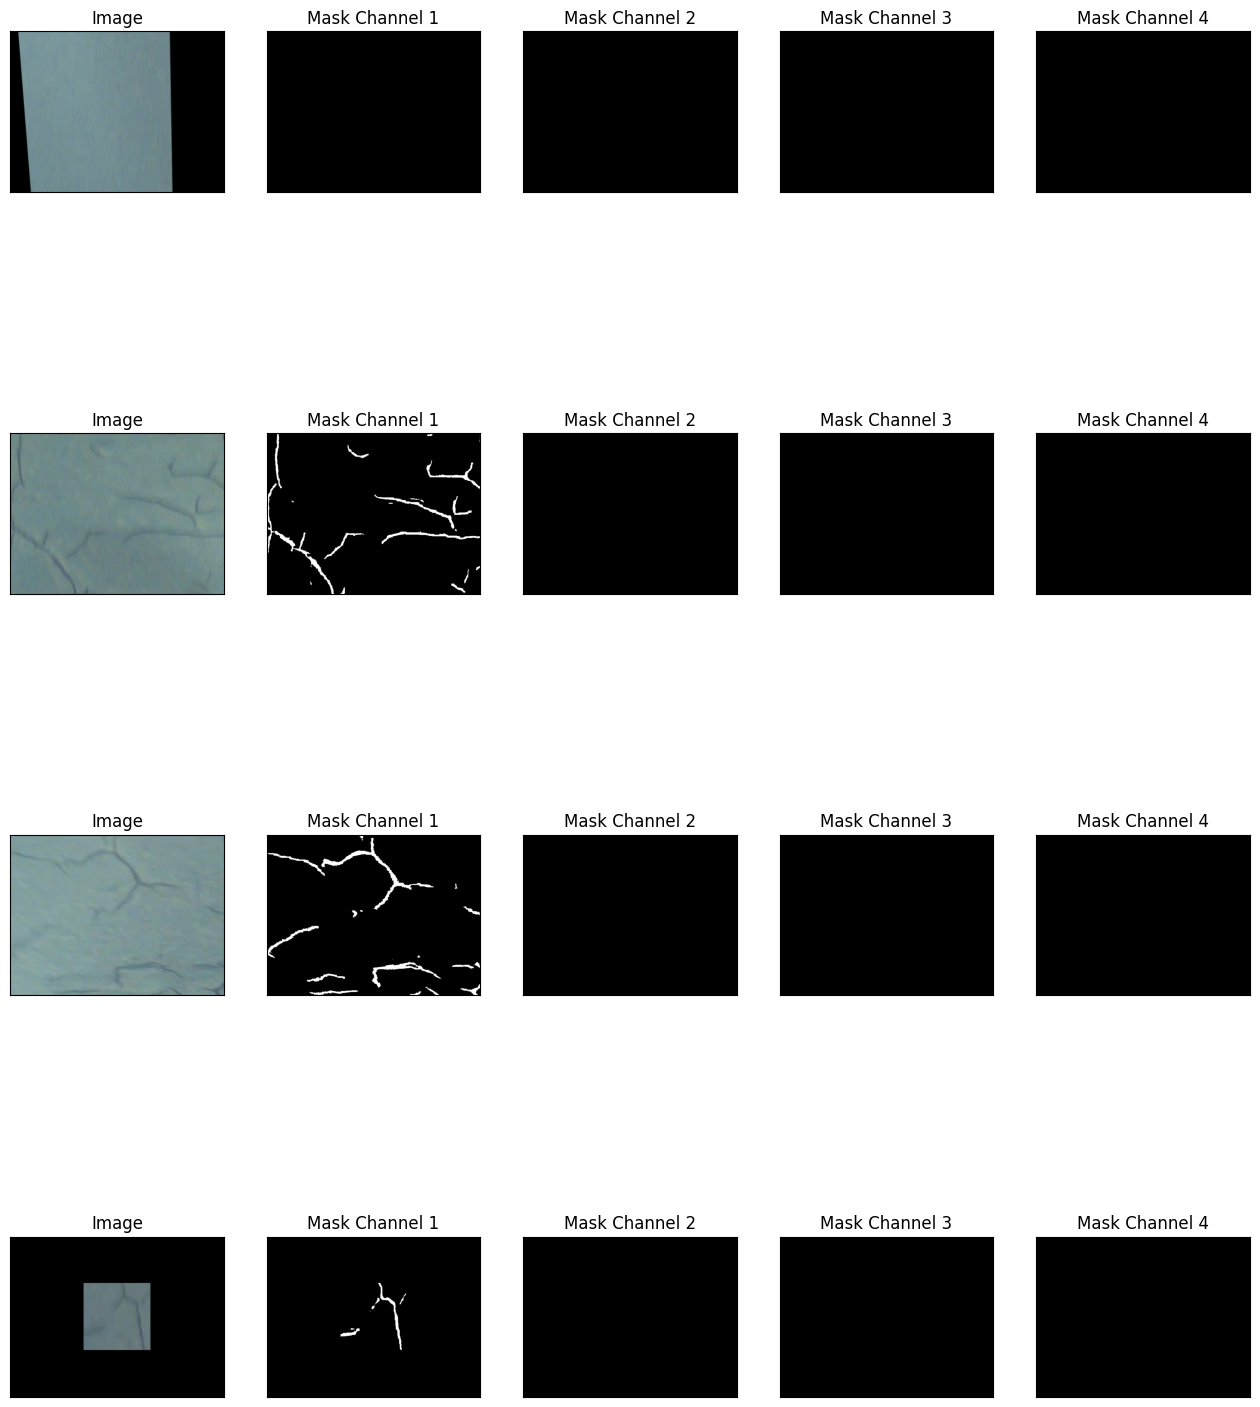

In [8]:
visualize(images,masks)

### Define and Compile the Model
Define the U-Net model using a pre-trained backbone (like ResNet) and specify the input shape, number of output classes, and activation function. Define the loss function and metrics to be used during training and compile the model with the Adam optimizer.

In [9]:
losses = Losses()
categorical_focal_dice_loss = losses.combine_losses(losses.categorical_focal_loss, losses.dice_loss)

In [10]:
metrics = Metrics()
metric = [
    metrics.iou_score,
    metrics.f1_score,
    metrics.dice,
    metrics.precision,
    metrics.recall
    
]

In [11]:
ARCHITECTURE_MAP = {
    'unet': Unet,
    'fpn': FPN,
    'linknet': LinkNet,
    'pspnet': PSPNet
}


arch_name = config['ARCHITECTURE'].lower()

if arch_name in ARCHITECTURE_MAP:
    ModelClass = ARCHITECTURE_MAP[arch_name]
    model = ModelClass(
        config['BACKBONE'],
        input_shape=(config['image_size'][0], config['image_size'][1], 3),
        classes=config['n_classes'],
        activation='sigmoid'
    )
else:
    raise ValueError(f"Unsupported architecture: {arch_name}. Available: {list(ARCHITECTURE_MAP.keys())}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
optim = tf.optimizers.Adam(config['LR'])
model.compile(optim, categorical_focal_dice_loss,metrics=metric)

### Define Callbacks for Training
Set up various callbacks to improve the training process. This includes saving the best model based on validation IOU score, reducing the learning rate on plateau, and logging training progress to a CSV file. These callbacks are passed to the model during training.


In [13]:

log_csv = CSVLogger('train_logs.csv',separator=',',append=False)
checkpoint = ModelCheckpoint(filepath=f"{config['BACKBONE']}_unet.keras", 
                             monitor='val_iou_score', verbose=1, save_best_only=True, mode='max')

callbacks = [checkpoint,ReduceLROnPlateau(),log_csv]
steps_per_epoch = len(os.listdir(config['paths']['x_train_dir'])) // config['BATCH_SIZE']


### Train the Model
Train the U-Net model on the training dataset using the specified configuration. We use the callbacks to monitor training progress and adjust parameters such as the learning rate. The training process includes a validation phase to track the model’s performance.


In [14]:
history = model.fit(
    train_dataset, 
    steps_per_epoch=steps_per_epoch, 
    epochs= config['EPOCHS'], 
    validation_data=valid_dataset, 
    callbacks= callbacks
)

Epoch 1/5


I0000 00:00:1745341074.856736     109 service.cc:148] XLA service 0x7bcdfc003610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745341074.858634     109 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745341080.176226     109 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1745341085.879553     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-04-22 16:58:05.986600: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng3{k11=2} for conv (f32[4,128,60,80]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,768,60,80]{3,2,1,0}, f32[128,768,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale"

556/556 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - dice_coefficient: 0.0300 - f1_score: 0.0300 - iou_score: 0.2296 - loss: 0.9635 - precision: 0.0153 - recall: 0.8820
Epoch 1: val_iou_score improved from -inf to 0.02965, saving model to resnet50_unet.keras
556/556 ━━━━━━━━━━━━━━━━━━━━ 395s 438ms/step - dice_coefficient: 0.0301 - f1_score: 0.0301 - iou_score: 0.2299 - loss: 0.9634 - precision: 0.0153 - recall: 0.8820 - val_dice_coefficient: 0.0316 - val_f1_score: 0.0316 - val_iou_score: 0.0297 - val_loss: 0.9917 - val_precision: 0.0225 - val_recall: 0.0526 - learning_rate: 1.0000e-04
Epoch 2/5
556/556 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - dice_coefficient: 0.1687 - f1_score: 0.1687 - iou_score: 0.2055 - loss: 0.6646 - precision: 0.0952 - recall: 0.7795
Epoch 2: val_iou_score improved from 0.02965 to 0.58043, saving model to resnet50_unet.keras
556/556 ━━━━━━━━━━━━━━━━━━━━ 256s 422ms/step - dice_coefficient: 0.1688 - f1_score: 0.1688 - iou_score: 0.2057 - loss: 0.6645 - precision: 0.0952 - reca

### Print Per-Class Validation Metrics
Print the evaluation metrics for each class (defect type). These include the average IoU, DSC, precision, recall, and F1 score. This gives a detailed breakdown of how well the model is performing on each defect type.


In [15]:
model.load_weights('resnet50_unet.keras')

In [16]:
label_names = ['surface_cracks', 'delamination', 'pinholes', 'unclassified_defects']
n_classes = config['n_classes']

class_iou = {i: [] for i in range(n_classes)}
class_dsc = {i: [] for i in range(n_classes)}
class_precision = {i: [] for i in range(n_classes)}
class_recall = {i: [] for i in range(n_classes)}
class_f1 = {i: [] for i in range(n_classes)}

for images, masks in tqdm(valid_dataset): 
    preds = model.predict(images,verbose=0)

    for i in range(images.shape[0]):  # loop through batch
        true_mask = masks[i].numpy()  # shape: (H, W, 4)
        pred_mask = preds[i]  # shape: (H, W, 4)

        true_mask = np.argmax(true_mask, axis=-1)
        pred_mask = np.argmax(pred_mask, axis=-1)

        for class_idx in range(n_classes):
            true_binary = (true_mask == class_idx).astype(np.uint8)
            pred_binary = (pred_mask == class_idx).astype(np.uint8)

            intersection = np.logical_and(true_binary, pred_binary).sum()
            union = np.logical_or(true_binary, pred_binary).sum()
            tp = intersection
            fp = np.logical_and(pred_binary == 1, true_binary == 0).sum()
            fn = np.logical_and(pred_binary == 0, true_binary == 1).sum()

            if true_binary.sum() == 0 and pred_binary.sum() == 0:
                continue  # skip class if not present

            iou = intersection / (union + 1e-7)
            dsc = (2 * intersection) / (2 * intersection + fp + fn + 1e-7)
            precision = tp / (tp + fp + 1e-7)
            recall = tp / (tp + fn + 1e-7)
            f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

            class_iou[class_idx].append(iou)
            class_dsc[class_idx].append(dsc)
            class_precision[class_idx].append(precision)
            class_recall[class_idx].append(recall)
            class_f1[class_idx].append(f1)

print("\n🔍 Per-class Validation Metrics:\n")
for i in range(n_classes):
    if len(class_iou[i]) == 0:
        print(f"{label_names[i]}: Not present in validation set.")
        continue
    print(f"{label_names[i]}:")
    print(f"  IOU:       {np.mean(class_iou[i]):.4f}")
    print(f"  DSC:       {np.mean(class_dsc[i]):.4f}")
    print(f"  Precision: {np.mean(class_precision[i]):.4f}")
    print(f"  Recall:    {np.mean(class_recall[i]):.4f}")
    print(f"  F1 Score:  {np.mean(class_f1[i]):.4f}\n")


100%|██████████| 556/556 [02:05<00:00,  4.43it/s]


🔍 Per-class Validation Metrics:

surface_cracks:
  IOU:       0.6922
  DSC:       0.8128
  Precision: 0.9996
  Recall:    0.6923
  F1 Score:  0.8128

delamination:
  IOU:       0.0198
  DSC:       0.0286
  Precision: 0.0202
  Recall:    0.0774
  F1 Score:  0.0286

pinholes:
  IOU:       0.0784
  DSC:       0.1093
  Precision: 0.1096
  Recall:    0.1444
  F1 Score:  0.1093

unclassified_defects:
  IOU:       0.0000
  DSC:       0.0001
  Precision: 0.0000
  Recall:    0.0017
  F1 Score:  0.0001

